In [49]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(f"Dataset/csv/loan_approval_dataset.csv")
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [8]:
data.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [7]:
#now we use the  following
#binary encoding(mainly for gender ,yes/no type features)
#one hot encoding (for non ordered data)
#label encoding for ordered data

In [9]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [12]:
#stripping any extra whitespace in column names
data.columns = data.columns.str.strip()
#now stripping any whitespace present inside the columnns
for col in ['education','self_employed','loan_status']:
    data[col] = data[col].str.strip()


In [14]:
#binary encoding
data['education'] = data['education'].map({'Graduate':0,'Not Graduate':1})
data['self_employed'] = data['self_employed'].map({"Yes":0,"No":1})
data['loan_status'] = data['loan_status'].map({"Approved":0,"Rejected":1})
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [20]:
#we make data for 
df_for_one_hot = pd.DataFrame({"Residential_area":np.random.choice(['urban','rural','semi-urban'],size =4269)})

In [21]:
df_for_one_hot.head()

,Residential_area
0,rural
1,semi-urban
2,semi-urban
3,rural
4,urban


In [25]:
data['residential_area'] = df_for_one_hot['Residential_area']

In [27]:
#now we perform one hot
data_encoded = pd.get_dummies(data,columns = ['residential_area'],drop_first = True)
data_encoded.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,residential_area_semi-urban,residential_area_urban
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,False,False
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,True,False
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,True,False
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,False,False
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,False,True


In [29]:
data_encoded = data_encoded.astype(int)

In [30]:
data_encoded.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,residential_area_semi-urban,residential_area_urban
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,0
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,1,0
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0,0
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,0,1


In [32]:
#for removing outliers
data.loan_amount.describe().astype(int)

count        4269
mean     15133450
std       9043362
min        300000
25%       7700000
50%      14500000
75%      21500000
max      39500000
Name: loan_amount, dtype: int64

<Axes: xlabel='loan_amount', ylabel='bank_asset_value'>

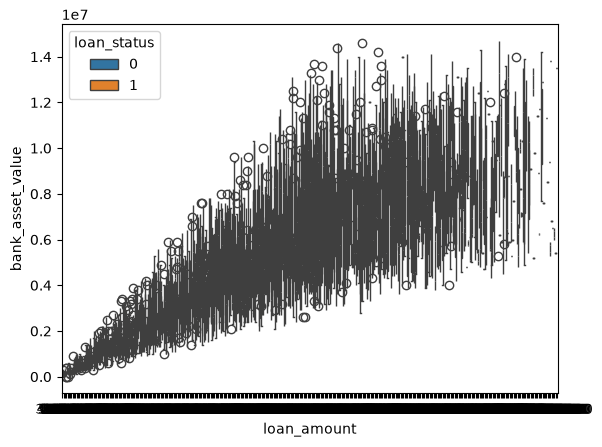

In [41]:
import seaborn as sns
sns.boxplot(data,x=data['loan_amount'],hue ='loan_status',y = 'bank_asset_value')

In [45]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,residential_area
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,rural
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,semi-urban
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,semi-urban
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,rural
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,urban


In [54]:
#now we want to make the numerical features to be normally distributed
#applying log transformation
data['annual_income_log'] = np.log(data['income_annum'])
data['loan_amount_log'] = np.log(data['loan_amount'])
data['total_asset_value'] = data['residential_assets_value']+data['commercial_assets_value']+data['luxury_assets_value']
data['total_assets_value_log'] = np.sqrt(data['total_asset_value'])

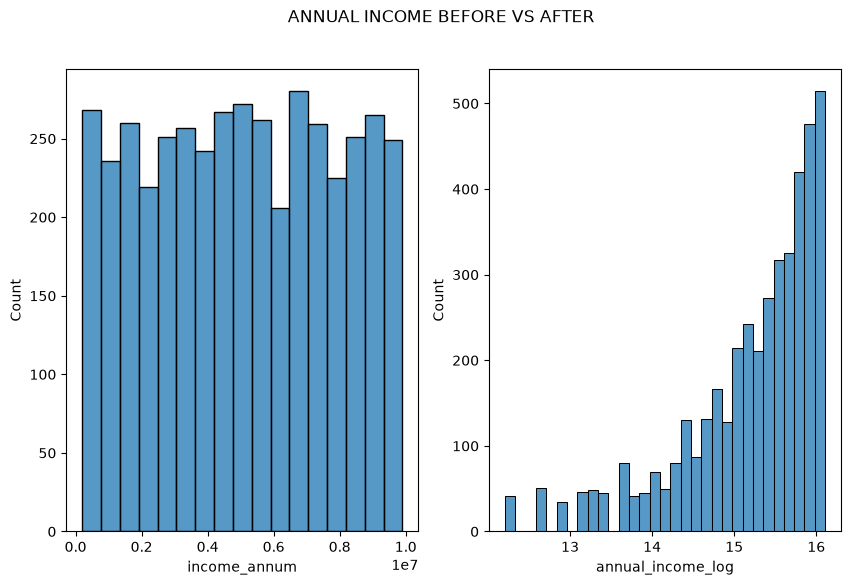

In [53]:
#now we compare before and after the transformation
plt.figure(figsize = (10,6))
plt.subplot(121)
sns.histplot(data['income_annum'])
plt.subplot(122)
sns.histplot(data['annual_income_log'])
plt.suptitle("ANNUAL INCOME BEFORE VS AFTER")
plt.show()

In [55]:
data.loan_status.value_counts(normalize = True)

loan_status
0    0.62216
1    0.37784
Name: proportion, dtype: float64

In [59]:
#now first convert one residenital-area into numercial features
data_encoded = pd.get_dummies(data,columns = ['residential_area'],drop_first = True)

In [60]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,residential_area,annual_income_log,loan_amount_log,total_asset_value,total_assets_value_log
0,1,2,0,1,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,rural,16.077274,17.213369,42700000,6534.523701
1,2,0,1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,semi-urban,15.226498,16.316947,13700000,3701.351105
2,3,3,0,1,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,semi-urban,16.023785,17.206658,44900000,6700.746227
3,4,3,0,1,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,rural,15.919645,17.239773,44800000,6693.280212
4,5,5,1,0,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,urban,16.097893,17.001863,50000000,7071.067812


In [61]:
#now we build base ML models to see which one suits this problems
from sklearn.model_selection import train_test_split
col_drop = ['residential_assets_value','commercial_assets_value','luxury_assets_value','loan_status','annual_income_log',
            'loan_amount_log','total_assets_value_log','residential_area']
X = data.drop(columns = col_drop)
y = data['loan_status']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
X.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,bank_asset_value,total_asset_value
0,1,2,0,1,9600000,29900000,12,778,8000000,42700000
1,2,0,1,0,4100000,12200000,8,417,3300000,13700000
2,3,3,0,1,9100000,29700000,20,506,12800000,44900000
3,4,3,0,1,8200000,30700000,8,467,7900000,44800000
4,5,5,1,0,9800000,24200000,20,382,5000000,50000000


In [64]:
#Min_max_scale these values also so that that distace doestn becomes an issue
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for col in ['bank_asset_value','total_asset_value','loan_amount','income_annum']:
    X_train[col] = scaler.fit_transform(X_train[[col]])
    X_test[col] = scaler.fit_transform(X_test[[col]])


In [65]:
X_train.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,bank_asset_value,total_asset_value
1675,1676,5,1,1,0.793814,0.755102,6,568,0.591837,0.434356
1164,1165,0,1,0,0.969072,0.859694,12,710,0.530612,0.883436
192,193,1,0,1,0.061856,0.066327,8,682,0.047619,0.073620
910,911,2,0,0,0.484536,0.326531,18,754,0.489796,0.341104
567,568,5,0,0,0.288660,0.275510,12,441,0.136054,0.222086


In [67]:
training_id = X_train['loan_id']
testing_id = X_test['loan_id']
X_train.drop('loan_id',axis =1)
X_test.drop('loan_id',axis =1)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,bank_asset_value,total_asset_value
1703,5,0,1,0.536082,0.510582,20,423,0.510638,0.424528
1173,2,0,1,0.587629,0.359788,8,599,0.468085,0.421833
308,3,0,1,0.969072,0.515873,14,452,0.460993,0.649596
1322,2,0,1,0.618557,0.608466,8,605,0.645390,0.564690
3271,3,1,0,0.577320,0.362434,12,738,0.588652,0.415094
...,...,...,...,...,...,...,...,...,...
912,4,0,1,0.237113,0.132275,10,592,0.198582,0.190027
443,2,0,1,0.773196,0.431217,6,555,0.595745,0.447439
1483,5,1,0,0.556701,0.293651,4,695,0.546099,0.371968
668,4,1,1,0.206186,0.216931,20,373,0.092199,0.142857


In [72]:
#train the models now and compare
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report


In [73]:
knn_accuracy_test = accuracy_score(y_test,knn.predict(X_test))
knn_accuracy_test

0.936768149882904

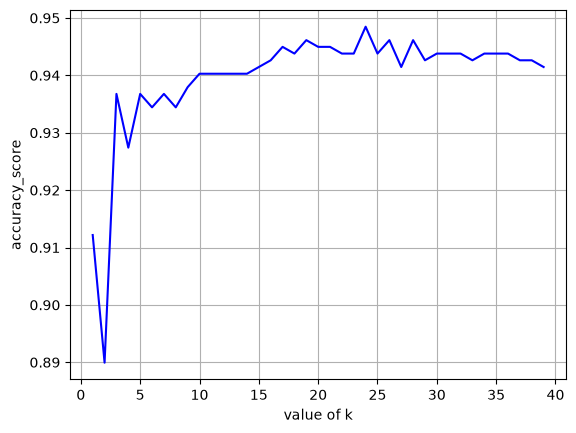

In [76]:
#finding best k
scores = []
for k in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train,y_train)
    scores.append(accuracy_score(y_test,knn.predict(X_test)))
x = np.arange(1,40)
plt.plot(x,scores,color = 'blue')
plt.xlabel('value of k')
plt.ylabel('accuracy_score')
plt.grid()
plt.show()

In [77]:
knn_final = KNeighborsClassifier(n_neighbors = 24)
knn_final.fit(X_train,y_train)
knn_accuracy = accuracy_score(y_test,knn_final.predict(X_test))
knn_accuracy

0.9484777517564403

In [80]:
#now build svm model
from sklearn.svm import SVC
svm_model = SVC(kernel = 'linear') #lets try with linear
svm_model.fit(X_train,y_train)
svm_accuracy_test = accuracy_score(y_test,svm_model.predict(X_test))
svm_accuracy_test


0.9098360655737705

In [81]:
svm_accuracy = svm_accuracy_test

In [82]:
#now Decision_tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'entropy',random_state = 42,max_depth= 4)
dt.fit(X_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [83]:
from sklearn.tree import plot_tree

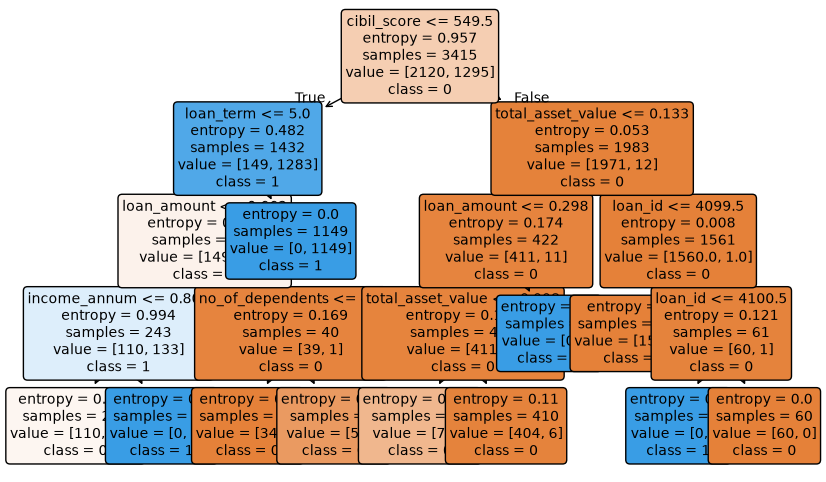

In [86]:
plt.figure(figsize = (10,6))
plot_tree(
    dt,
    feature_names = X.columns,
    class_names = ['0','1'],
    rounded = True,
    filled = True,
    fontsize = 10)
plt.show()


In [88]:
dt_accuracy = accuracy_score(y_test,dt.predict(X_test))
dt_accuracy

0.9637002341920374

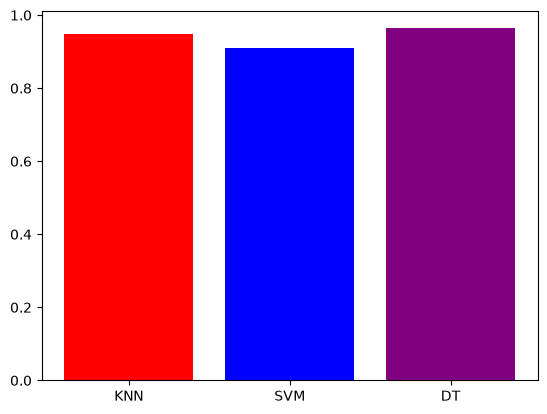

In [92]:
#now compare accuracies
plt.figure(1)
model_name = ['KNN','SVM','DT']
score_acc = [knn_accuracy,svm_accuracy,dt_accuracy]
plt.bar(x = model_name,height = score_acc,color = ['red','blue','purple'])
plt.show()

In [93]:
#we see that knn and dt are exceptionally well 
#now we do feature engineering part 2  - LOFO 
#feature importance per feature

In [96]:
feature_importance = {}  #dictionary with feature name and its importance
for feature in X_train.columns:
    #reduced set
    X_train_red = X_train.drop(columns = [feature])
    X_test_red = X_test.drop(columns = [feature]) 

    #fit the model
    dt.fit(X_train_red,y_train)

    #reduced accuracy
    reduced_accuracy = accuracy_score(y_test,dt.predict(X_test_red))
    feature_importance[feature] = dt_accuracy - reduced_accuracy

 #sort the list 
sorted_importance = sorted(feature_importance.items(),key= lambda x:x[1],reverse = True)

#print
print("LOFO Results")
for feature,drop in sorted_importance:
    print(f"{feature} Performance drop -> {drop:.4f}")

LOFO Results
cibil_score Performance drop -> 0.3419
loan_term Performance drop -> 0.0070
loan_amount Performance drop -> 0.0047
total_asset_value Performance drop -> 0.0012
no_of_dependents Performance drop -> 0.0000
education Performance drop -> 0.0000
self_employed Performance drop -> 0.0000
bank_asset_value Performance drop -> 0.0000
loan_id Performance drop -> -0.0012
income_annum Performance drop -> -0.0023


In [97]:
feature_importance = {}  #dictionary with feature name and its importance
for feature in X_train.columns:
    #reduced set
    X_train_red = X_train.drop(columns = [feature])
    X_test_red = X_test.drop(columns = [feature]) 

    #fit the model
    knn.fit(X_train_red,y_train)

    #reduced accuracy
    reduced_accuracy = accuracy_score(y_test,knn.predict(X_test_red))
    feature_importance[feature] = knn_accuracy - reduced_accuracy

 #sort the list 
sorted_importance = sorted(feature_importance.items(),key= lambda x:x[1],reverse = True)

#print
print("LOFO Results for knn")
for feature,drop in sorted_importance:
    print(f"{feature} Performance drop -> {drop:.4f}")

LOFO Results for knn
cibil_score Performance drop -> 0.3349
no_of_dependents Performance drop -> 0.0070
education Performance drop -> 0.0070
self_employed Performance drop -> 0.0070
income_annum Performance drop -> 0.0070
loan_amount Performance drop -> 0.0070
loan_term Performance drop -> 0.0070
bank_asset_value Performance drop -> 0.0070
total_asset_value Performance drop -> 0.0070
loan_id Performance drop -> -0.0070


In [98]:
#BUILDING THE FINAL MODEL

In [101]:
final_model =DecisionTreeClassifier(criterion = 'entropy',random_state = 42)
final_model.fit(X_train,y_train)
param_grid = {
    "max_depth" : [3,4,5,6,7],
    'min_samples_split' : [4,5,6,7,8],
    'min_samples_leaf' : [1,5,10,15,20],
    'max_leaf_nodes': [10,20,50]
}

In [105]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = final_model,
                          param_grid = param_grid,
                          n_jobs = -1,cv = 5,scoring = 'accuracy',
                          verbose = 2)
grid_search.fit(X_train,y_train)
best_model = grid_search.best_estimator_
final_accuracy = accuracy_score(y_test,best_model.predict(X_test))
final_accuracy

Fitting 5 folds for each of 375 candidates, totalling 1875 fits


0.9707259953161592

In [106]:
#hurray 97.07 % accurate
#lets see classification_report
from sklearn.metrics import classification_report
pred = best_model.predict(X_test)
c_report = classification_report(y_test,pred)
c_report

'              precision    recall  f1-score   support\n\n           0       0.96      1.00      0.98       536\n           1       1.00      0.92      0.96       318\n\n    accuracy                           0.97       854\n   macro avg       0.98      0.96      0.97       854\nweighted avg       0.97      0.97      0.97       854\n'

In [107]:
#everything nicee :)
#HERE THIS PROJECT COMES TO AN END